In [1]:
#--------------------------------------------------------------------------------------------------------------
#
#  Code: CCC05_Multi_State_LangGraph_RAG_for_CCAR_Model_Scoring_20260706.ipynb
#
#  Goal: This proof of concept demonstrates an enterprise Agentic AI workflow for CCAR risk scoring and model governance.
#        Traditional deterministic analytics (data validation, feature engineering, model scoring, and performance evaluation) are combined with
#        agentic capabilities including conditional routing, retrieval-augmented generation (RAG), recommendation generation, human-in-the-loop approval,
#        deterministic SQL tool use, and executive summarization. The workflow illustrates how LLM-powered agents can orchestrate governance decisions
#        while leveraging conventional machine learning and rule-based components for reliable production execution.
#
# Process: To read in Jingru Chen's simulated CCAR data, then conduct data validation, scoring, performance evaluation, HILT, Deterministic SQL and Executive Summary.
#
#        This Agentic AI framework leverages multi-agent orchestration. Specially, it will implement multiple agents, including
#
#        (01) Agent 1 – Upload the scoring file             step_1_uploading           _01_agent_upload
#        (02) Agent 2 - Data Validation                     _02_DataValidator          _02_agent_DataValidator
#        (03) Agent 3 – FeatureEngineer                     _03_FeatureEngineer        _03_agent_FeatureEngineer
#        (04) Agent 4 – Monthly Scoring &                   _04_Model_Scorer           _04_agent_Model_Scorer
#        (05) Agent 5 - Performance Evaluation              _05_PerformanceEvaluator   _05_agent_PerformanceEvaluator
#        (06) Agent 6 – Conditional Router                  _06_ConditionalRouter      _06_agent_conditional_router
#        (07) Agent 7 – Reporting Agent                     _07_ReportingAgent         _07_agent_reporting
#        (08) Agent 8 – RAG Agent for goverance/monitoring  _08_RAG_Agent              _08_agent_RAG_goverance_monitoring
#        (09) Agent 9 – Recommendation Agent                _09_RecommendationAgent    _09_agent_recommendation
#        (10) Step 10 – Human-in-the-Loop                   _10_HumanApproval          _10_agent_human_approval
#        (11) Agent 11 – Deterministic SQL Agent            _11_DeterministicSQLAgent  _11_agent_DeterministicSQLAgent
#        (12) Agent 12 – Executive                          _12_ExecutiveSummaryAgent  _12_agent_ExecutiveSummaryAgent
#
#        Jingru Chen
#        2026-07-06
#
#---------------------------------------------------------------------------------------------------------------

In [2]:

from datetime import datetime
from zoneinfo import ZoneInfo

start = datetime.now( ZoneInfo("America/New_York"))

print( start.strftime("%Y-%m-%d %H:%M:%S %Z"))     # 2026-03-17 17:34:58 EDT
print( start.strftime("%Y-%m-%d %I:%M:%S %p %Z"))  # 2026-03-17 05:34:58 PM ED

2026-07-06 15:16:32 EDT
2026-07-06 03:16:32 PM EDT


## Step 0: Set up and install various Python packages

In [3]:
from sentence_transformers import SentenceTransformer

# Current: 384 dimensions (Fast, but lower capacity)
# embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Upgrade: 768 dimensions (Higher accuracy, captures more nuance)
# embedding_model = SentenceTransformer("all-mpnet-base-v2")

# Extreme Upgrade: 1024+ dimensions (e.g., using BGE or Instructor models)
embedding_model = SentenceTransformer("BAAI/bge-large-en-v1.5")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [4]:
# %pip install pymupdf

# PyMuPDF is a tool for working with PDF files using Python.
# PyMuPDF over others (like PyPDF2 or PDFMiner)?
# Performance: It is significantly faster than most other Python PDF libraries because the heavy lifting is done by the underlying C library.

In [5]:
# --- Dependency Installer ---

# !pip install -q langchain-openai langgraph pandas pymupdf
# --- To add -q will makes the installation "quiet," so it doesn't flood my notebook with long, messy installation logs.
# --- For testing purpose, I still print all log.

!pip install langchain-openai langgraph langsmith pandas pymupdf

In [6]:
!pip install python-dotenv

In [7]:
# !uv pip install pymupdf

# uv is a newer tool designed to be much faster than pip.

In [8]:
import os
import pandas as pd
import json
from typing import List
import fitz
import re
import numpy as np
import glob
import matplotlib.pyplot as plt
import json

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

import sqlite3

# Create an in-memory database for our CCAR simulated data
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

from scipy.stats import ks_2samp

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from pydantic import BaseModel, Field

from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from typing import TypedDict, List, Dict, Any
from langgraph.graph import StateGraph, END

from openai import OpenAI
from langchain_openai import ChatOpenAI
from langsmith import Client
from langsmith.utils import LangSmithConflictError
from IPython.display import Image, display

pd.set_option("display.max_colwidth", None)   # Show full text
pd.set_option("display.max_columns", None)    # Show all columns
pd.set_option("display.width", None)          # Unlimited display width
pd.set_option("display.expand_frame_repr", False)

## Step 1: Connect to my data folder in Google drive

In [9]:
pwd

'/content'

In [10]:
ls -lt

total 8
drwx------ 5 root root 4096 Jul  6 14:44 drive/
drwxr-xr-x 1 root root 4096 Jun  4 13:32 sample_data/


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# Go to the level of sample_data in my Google Drive
path = "/content/drive/MyDrive/Colab Notebooks/sample_data"

# Verify the path after the above connecting step
print(os.getcwd())

# List all files unver the sample_data folder
os.listdir(path)

/content


['chroma.sqlite3',
 'Jingru_WFC_Autograph_Visa_Card_statement_202606.pdf',
 'Jingru_WFC_Autograph_Visa_Card_statement_202605.pdf',
 'Jingru_WFC_Autograph_Visa_Card_statement_202604.pdf',
 '.env',
 'CCAR_Mortgage_data_for_model_DEV_20260319_01.csv']

### Step 1-B: Upload my API_KEYs for various LLM and LangSmith

In [13]:
from dotenv import load_dotenv

load_dotenv("/content/drive/MyDrive/Colab Notebooks/sample_data/.env")

# =========================
# OPENAI KEY
# =========================
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
print(f"-----------------1-B-1: Print of first 20 characters of my OPENAI_API_KEY -----: {OPENAI_API_KEY[:20]} " )  # check the first 20 charaacters of my OPENAI_API_KEY

# =========================
# LANGSMITH CONFIG
# =========================

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")

# IMPORTANT: correct project name
os.environ["LANGSMITH_PROJECT"] = "JCHEN-credit-risck_scoring-validation-langgraph"

# =========================
# SAFE PRINT (correct variable)
# =========================
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")

print(f"---------------- 1-B-2: Print of first 20 characters of my LANGSMITH_API_KEY---: {LANGSMITH_API_KEY[:20]} ")

print(os.getenv("LANGSMITH_TRACING"))
print(os.getenv("LANGSMITH_PROJECT"))

# =========================
# 3. Initialize the client
# =========================
client = Client()

# =========================
# 4. Ensure the project exists
# =========================
project_name = "JCHEN-credit-risck_scoring-validation-langgraph"

try:
    client.create_project(
        project_name=project_name,
        description="Credit Risk Scoring + Validation pipeline"
    )
    print(f"Successfully created project: {project_name}")

except LangSmithConflictError:
    print(f"Project '{project_name}' already exists. Proceeding with existing project.")

-----------------1-B-1: Print of first 20 characters of my OPENAI_API_KEY -----: sk-proj-fezFts2agCx8 
---------------- 1-B-2: Print of first 20 characters of my LANGSMITH_API_KEY---: lsv2_pt_5f67d91ddcbc 
true
JCHEN-credit-risck_scoring-validation-langgraph
Project 'JCHEN-credit-risck_scoring-validation-langgraph' already exists. Proceeding with existing project.


In [14]:
openai_client = OpenAI(api_key=OPENAI_API_KEY)
openai_client

### Step 1-C: Mini test for connecting to LangSmith

### Step 1-D:

In [15]:

x_list=['original_balance', 'credit_score_orig', 'loan_to_value_orig', 'interest_rate', 'loan_term_months',
        'delta_Unemployment1',
       'delta_Mortgage_rate1', 'delta_House_Price_Index__Level1',
       'delta_Unemployment3', 'delta_Mortgage_rate3',
       'delta_House_Price_Index__Level3', 'delta_Unemployment6',
       'delta_Mortgage_rate6', 'delta_House_Price_Index__Level6',
       'delta_Unemployment12', 'delta_Mortgage_rate12',
       'delta_House_Price_Index__Level12', 'delta_Unemployment24',
       'delta_Mortgage_rate24', 'delta_House_Price_Index__Level24']

x_list_v2=['original_balance', 'credit_score_orig', 'loan_to_value_orig', 'interest_rate',
        'delta_Unemployment1',
       'delta_Unemployment3',
       'delta_Unemployment6',
       'delta_Mortgage_rate6', 'delta_House_Price_Index__Level6',
       'delta_Unemployment12',
       'delta_Unemployment24' ]

x_list_v3= ['original_balance', 'credit_score_orig', 'loan_to_value_orig', 'interest_rate']

# y_list= ['flag_default']

decile_list = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

pd_model = 'ccar_pd_model_2026-03-22.pkl'
pd_model_path = "/content/drive/MyDrive/Colab Notebooks/ccar_pd_model_2026-03-22.pkl"

llm_model_name = "gpt-4o-mini"

# Use the full Absolute Path:
pd_input_file = "/content/drive/MyDrive/Colab Notebooks/CCAR_Mortgage_data_for_model_DEV_20260319_01.csv"

# pd_vintage = 201604
pd_x_list = x_list_v2
pd_y = 'flag_default'
pd_threshold = 0.50      ### pd_threshold value will be used in the agent_a step.

my_scoring_vintage = '201604'

### Step 1-E: CCAR Production Agent

## Step 2: Upload simulated monthly CCAR file

### Step 2-01 / Step 2-02: Upload the scoring file and Create summary information

In [16]:
# ==================================================
# I. Classes
# ==================================================


In [17]:
def step_1_uploading(input_path, var_list ):

    validation_report = []

    def add_validation(check, status, details):
        validation_report.append({
            "Validation": check,
            "Status": status,
            "Details": details
        })

    # 01. File exists
    if os.path.exists(input_path):
        add_validation("File exists", "PASS", input_path)
    else:
        add_validation("File exists", "FAIL", input_path)
        raise FileNotFoundError(f"{input_path} does not exist.")

    # 02. Empty file
    file_size = os.path.getsize(input_path)

    if file_size > 0:
        add_validation("Empty file", "PASS", f"{file_size} bytes")
    else:
        add_validation("Empty file", "FAIL", "0 bytes")
        raise ValueError("Input file is empty.")

    # 03. Read file
    df = pd.read_csv(input_path)

    upload_report = pd.DataFrame(validation_report)

    print("---------------- 1-A-01: Validation Summary Report ----------------")
    print(df.yrmo.value_counts())

    print("\n---------------- 1-A-02: Summary of Numerical Columns ----------------")
    print(df[ var_list ].describe(decile_list))

    return df, upload_report

In [18]:
class _02_DataValidator:

    def __init__(self, df, required_columns, numeric_columns, target_col="flag_default"):

        self.df = df
        self.required_columns = required_columns
        self.numeric_columns = numeric_columns
        self.target_col = target_col
        self.report = []

    def add_result(self, check, status, details):

        self.report.append({
            "Validation": check,
            "Status": status,
            "Details": details
        })

    def _02_A_validate_required_columns(self):

        missing_cols = list(set(self.required_columns) - set(self.df.columns))

        if len(missing_cols) == 0:
            self.add_result(
                "Required columns",
                "PASS",
                f"{len(self.required_columns)} required columns found"
            )
        else:
            self.add_result(
                "Required columns",
                "FAIL",
                f"Missing columns: {missing_cols}"
            )
            raise Exception(f"Missing columns: {missing_cols}")

    def _02_B_validate_duplicates(self):

        dup = self.df.duplicated().sum()

        if dup == 0:
            self.add_result(
                "Duplicate Rows",
                "PASS",
                "No duplicates"
            )
        else:
            self.add_result(
                "Duplicate Rows",
                "WARNING",
                f"{dup} duplicate rows"
            )

    def _02_C_check_missing(self, threshold=10):

        missing_pct = self.df.isna().mean() * 100
        high_missing = missing_pct[missing_pct > threshold].sort_values(ascending=False)

        if len(high_missing) == 0:
            self.add_result(
                "Missing values",
                "PASS",
                f"No variable >{threshold}% missing"
            )
        else:
            details = ", ".join([
                f"{col}: {val:.1f}%"
                for col, val in high_missing.items()
            ])

            self.add_result(
                "Missing values",
                "WARNING",
                details
            )

    def _02_D_check_yrmo(self):

        if "yrmo" in self.df.columns:
            yrmo_count = self.df["yrmo"].nunique()

            self.add_result(
                "YRMO distribution",
                "PASS",
                f"{yrmo_count} unique months"
            )
        else:
            self.add_result(
                "YRMO distribution",
                "WARNING",
                "yrmo column not found"
            )

    def _02_E_check_target(self):

        if self.target_col in self.df.columns:

            target_values = sorted(self.df[self.target_col].dropna().unique())

            if set(target_values).issubset({0, 1}):

                bad_rate = self.df[self.target_col].mean() * 100

                self.add_result(
                    "Target distribution",
                    "PASS",
                    f"Bad rate = {bad_rate:.2f}%"
                )

            else:
                self.add_result(
                    "Target distribution",
                    "FAIL",
                    f"Unexpected target values: {target_values}"
                )
        else:
            self.add_result(
                "Target distribution",
                "WARNING",
                f"{self.target_col} column not found"
            )

    def _02_F_check_outliers(self):

        outlier_count = 0

        for col in self.numeric_columns:

            if col in self.df.columns and pd.api.types.is_numeric_dtype(self.df[col]):

                q1 = self.df[col].quantile(0.01)
                q99 = self.df[col].quantile(0.99)

                outlier_count += (
                    (self.df[col] < q1) |
                    (self.df[col] > q99)
                ).sum()

        if outlier_count == 0:
            self.add_result(
                "Outliers",
                "PASS",
                "No extreme outliers detected"
            )
        else:
            self.add_result(
                "Outliers",
                "WARNING",
                f"{outlier_count} values outside 1%-99% range"
            )

    def run_all(self):

        self._02_A_validate_required_columns()
        self._02_B_validate_duplicates()
        self._02_C_check_missing()
        self._02_D_check_yrmo()
        self._02_E_check_target()
        self._02_F_check_outliers()

        return pd.DataFrame(self.report)


In [19]:
# data_1_uploaded, upload_report = step_1_uploading( pd_input_file , x_list_v3 )

# validator = _02_DataValidator(
#     df=data_1_uploaded,
#     required_columns=x_list_v2,
#     numeric_columns=x_list_v3,
#     target_col="flag_default"
# )

# validation_report = validator.run_all()

# final_report = pd.concat(
#     [upload_report, validation_report],
#     ignore_index=True
# )

# print("\n---------------- 2-A-01: Validation Summary Report ----------------")
# final_report

### Step 2-03: FeatureEngineer for simulated CCAR file (in this proof-of-concept project, just keep as simple)

In [20]:
class _03_FeatureEngineer:

    def __init__(self, df):
        self.df = df.copy()

    def cap_outliers(self):
        # optional placeholder
        return self

    def handle_missing_values(self):
        # optional placeholder
        return self

    def create_model_features(self):
        # optional placeholder
        return self

    def risk_bucket_creation(self):
        # optional placeholder
        return self

    def categorical_encoding(self):
        # optional placeholder
        return self

    def categorical_encoding(self):
        # optional placeholder
        return self

    def date_feature_selection(self):
        # optional placeholder
        return self

    def run_all(self):
        self.cap_outliers()
        self.handle_missing_values()
        self.create_model_features()
        self.risk_bucket_creation()
        self.categorical_encoding()
        self.categorical_encoding()
        self.date_feature_selection()
        return self.df

# feature_engineer = _03_FeatureEngineer( data_1_uploaded )

# data_2_features = feature_engineer.run_all()

# data_2_features.shape

### Srtep 2-04: Run Model Scoring for simulated CCAR file

In [21]:
class _04_Model_Scorer:

    def __init__(self, df, model, x_list, y_target, pd_threshold):
        self.df = df.copy()
        self.model = model
        self.x_list = x_list
        self.y_target = y_target
        self.pd_threshold = pd_threshold

    def _scoring_action(self, vintage):

        try:
            df_v = self.df.loc[
                self.df["report_yrmo"].astype(str) == str(vintage)
            ].reset_index(drop=True)

            if df_v.empty:
                return None, {"Vintage": vintage, "Status": "Skipped (No Data)"}

            X = df_v[self.x_list]
            y = df_v[self.y_target]

            y_proba = self.model.predict_proba(X)[:, 1]
            y_pred = (y_proba >= self.pd_threshold).astype(int)

            df_v["pd_score"] = y_proba
            df_v["pred_flag"] = y_pred

            tn, fp, fn, tp = confusion_matrix(
                y, y_pred, labels=[0, 1]
            ).ravel()

            report = {
                "Vintage": vintage,
                "Status": "Success",
                "Count": len(df_v),
                "Avg_PD": y_proba.mean(),
                "Precision": precision_score(y, y_pred, zero_division=0),
                "Recall": recall_score(y, y_pred, zero_division=0),
                "F1": f1_score(y, y_pred, zero_division=0),
                "TP": tp,
                "FN": fn,
                "TN": tn,
                "FP": fp
            }

            return df_v, report

        except Exception as e:
            return None, {"Vintage": vintage, "Status": f"Error: {str(e)}"}

    def run_all(self, vintage):
        df_scored, report = self._scoring_action(vintage)
        report_df = pd.DataFrame([report])
        return df_scored, report_df

In [22]:
# data_3_scoring_201605, scoring_report_201605 = model_scorer.run_all("201605")

# print(data_3_scoring_201605.shape)
# display(scoring_report_201605 )

### Step 2-05: Performance Evaluation


In [23]:
#

class _05_PerformanceEvaluator:

    def __init__(self, df_scored, y_target, score_col="pd_score", pred_col="pred_flag"):

        self.df = df_scored.copy()
        self.y_target = y_target
        self.score_col = score_col
        self.pred_col = pred_col
        self.report = []

    def add_result(self, metric, status, value=None, details=""):

        self.report.append({
            "Metric": metric,
            "Status": status,
            "Value": value,
            "Details": details
        })

    def check_auc(self, threshold_warning=0.65, threshold_fail=0.60):

        y = self.df[self.y_target]
        score = self.df[self.score_col]

        if y.nunique() < 2:
            self.add_result(
                "AUC",
                "SKIPPED",
                None,
                "AUC requires both good and bad observations"
            )
            return

        auc = roc_auc_score(y, score)

        if auc < threshold_fail:
            status = "FAIL"
        elif auc < threshold_warning:
            status = "WARNING"
        else:
            status = "PASS"

        self.add_result("AUC", status, round(auc, 4))

    def check_ks(self, threshold_warning=0.25, threshold_fail=0.20):

        good = self.df.loc[self.df[self.y_target] == 0, self.score_col]
        bad = self.df.loc[self.df[self.y_target] == 1, self.score_col]

        if len(good) == 0 or len(bad) == 0:
            self.add_result(
                "KS",
                "SKIPPED",
                None,
                "KS requires both good and bad observations"
            )
            return

        ks = ks_2samp(bad, good).statistic

        if ks < threshold_fail:
            status = "FAIL"
        elif ks < threshold_warning:
            status = "WARNING"
        else:
            status = "PASS"

        self.add_result("KS", status, round(ks, 4))

    def check_classification_metrics(self):

        y = self.df[self.y_target]
        y_pred = self.df[self.pred_col]

        self.add_result(
            "Precision",
            "INFO",
            round(precision_score(y, y_pred, zero_division=0), 4)
        )

        self.add_result(
            "Recall",
            "INFO",
            round(recall_score(y, y_pred, zero_division=0), 4)
        )

        self.add_result(
            "F1",
            "INFO",
            round(f1_score(y, y_pred, zero_division=0), 4)
        )

    def check_bad_rate(self):

        actual_bad_rate = self.df[self.y_target].mean()
        predicted_bad_rate = self.df[self.pred_col].mean()
        avg_pd = self.df[self.score_col].mean()

        self.add_result(
            "Actual Bad Rate",
            "INFO",
            round(actual_bad_rate, 4)
        )

        self.add_result(
            "Predicted Bad Rate",
            "INFO",
            round(predicted_bad_rate, 4)
        )

        self.add_result(
            "Average PD",
            "INFO",
            round(avg_pd, 4)
        )

    def run_all(self):

        self.check_auc()
        self.check_ks()
        self.check_classification_metrics()
        self.check_bad_rate()

        return pd.DataFrame(self.report)

In [24]:
# evaluator = _05_PerformanceEvaluator(
#     df_scored=data_3_scoring,
#     y_target="flag_default",
#     score_col="pd_score",
#     pred_col="pred_flag"
# )

# performance_report = evaluator.run_all()

# display(performance_report)

### Step 2-06: Conditional Routing

If validation FAIL        → stop pipeline
If AUC/KS/Recall FAIL     → route to Recommendation Agent
If performance WARNING    → route to RAG Agent + Recommendation Agent
If performance PASS       → route to Reporting Agent
If human approval needed  → route to Human Approval

In [25]:
class _06_ConditionalRouter:

    def __init__(self, validation_report, scoring_report, performance_report=None):
        self.validation_report = validation_report
        self.scoring_report = scoring_report
        self.performance_report = performance_report
        self.route_decision = None
        self.reason = None

    def _get_status_col(self, df):
        if df is None:
            return None
        if "Status" in df.columns:
            return "Status"
        if "status" in df.columns:
            return "status"
        return None

    def check_validation_failure(self):
        status_col = self._get_status_col(self.validation_report)

        if status_col and "FAIL" in self.validation_report[status_col].values:
            self.route_decision = "STOP"
            self.reason = "Data validation failed"
            return True

        return False

    def check_scoring_failure(self):
        status_col = self._get_status_col(self.scoring_report)

        if status_col is None:
            return False

        status_list = self.scoring_report[status_col].astype(str).tolist()

        if any("Error" in s for s in status_list):
            self.route_decision = "STOP"
            self.reason = "Model scoring error"
            return True

        if any("Skipped" in s for s in status_list):
            self.route_decision = "HUMAN_REVIEW"
            self.reason = "No data found for selected vintage"
            return True

        return False

    def check_performance_warning(self):
        status_col = self._get_status_col(self.performance_report)

        if status_col is None:
            return False

        if "FAIL" in self.performance_report[status_col].values:
            self.route_decision = "RECOMMENDATION_AGENT"
            self.reason = "Model performance failed"
            return True

        if "WARNING" in self.performance_report[status_col].values:
            self.route_decision = "RAG_AGENT"
            self.reason = "Model performance warning"
            return True

        return False

    def default_route(self):
        self.route_decision = "REPORTING_AGENT"
        self.reason = "All checks passed"

    def run_all(self):
        if self.check_validation_failure():
            return self.get_decision()

        if self.check_scoring_failure():
            return self.get_decision()

        if self.check_performance_warning():
            return self.get_decision()

        self.default_route()
        return self.get_decision()

    def get_decision(self):
        return {
            "route_decision": self.route_decision,
            "route_reason": self.reason,
            "route_result": self.route_decision
        }

In [26]:
# router = _06_ConditionalRouter(
#     validation_report=final_report,
#     scoring_report=scoring_report,
#     performance_report=performance_report
# )

# route_result = router.run_all()

# route_result

### Step 2-07: Reporting Summary

In [27]:
class _07_ReportingAgent:

    def __init__(self, validation_report, scoring_report, performance_report, route_result):
        self.validation_report = validation_report
        self.scoring_report = scoring_report
        self.performance_report = performance_report
        self.route_result = route_result

    def run_all(self):

        validation_summary = self.validation_report["Status"].value_counts().to_dict()

        if self.scoring_report is not None and len(self.scoring_report) > 0:
            scoring = self.scoring_report.iloc[0].to_dict()
        else:
            scoring = {}

        technical_report = pd.DataFrame([{
            "Validation PASS": validation_summary.get("PASS", 0),
            "Validation WARNING": validation_summary.get("WARNING", 0),
            "Validation FAIL": validation_summary.get("FAIL", 0),

            "Scoring Status": scoring.get("Status"),
            "Vintage": scoring.get("Vintage"),
            "Record Count": scoring.get("Count"),
            "Average PD": scoring.get("Avg_PD"),
            "Precision": scoring.get("Precision"),
            "Recall": scoring.get("Recall"),
            "F1": scoring.get("F1"),

            "Route Decision": self.route_result.get("route_decision"),
            "Route Reason": self.route_result.get("reason")
        }])

        return technical_report

In [28]:
# reporting_agent = _07_ReportingAgent(
#     validation_report=final_report,
#     scoring_report=scoring_report,
#     performance_report=performance_report,
#     route_result=route_result
# )

# final_summary_report = reporting_agent.run_all()

# display(final_summary_report)

### Step 2-08: RAG

In [29]:
# Future's steps:

# FAISS / Chroma vector database
# OpenAI embeddings
# LangChain retriever
# LlamaIndex retriever
# internal policy PDFs
# model validation documents
# MRM standards
# NIST AI RMF documents

In [30]:
sample_knowledge_base = [
    "If model recall drops below threshold, investigate data drift, feature distribution shift, and target definition changes.",
    "If AUC or KS deteriorates materially, perform model monitoring review and consider recalibration.",
    "If data validation fails, stop scoring and escalate to data owner.",
    "If predicted bad rate deviates materially from actual bad rate, review calibration and cutoff strategy."
]

In [31]:
class _08_RAG_Agent:

    def __init__(self, route_result, performance_report, knowledge_base):
        self.route_result = route_result
        self.performance_report = performance_report
        self.knowledge_base = knowledge_base

    def build_query(self):

        reason = self.route_result.get("reason", "")

        issues = self.performance_report[
            self.performance_report["Status"].isin(["WARNING", "FAIL"])
        ]

        metrics = ", ".join(issues["Metric"].tolist())

        query = (
            f"Model monitoring issue: {reason}. "
            f"Problematic metrics: {metrics}. "
            f"Retrieve relevant model governance monitoring guidance."
        )

        return query

    def retrieve_documents(self, query):

        relevant_docs = []

        for doc in self.knowledge_base:
            if any(word.lower().strip(".,") in doc.lower() for word in query.split()):
                relevant_docs.append(doc)

        return relevant_docs[:5]

    def run_all(self):

        query = self.build_query()

        retrieved_docs = self.retrieve_documents(query)

        if retrieved_docs:
            rag_answer = " ".join(retrieved_docs)
        else:
            rag_answer = "No relevant governance monitoring guidance found."

        return {
            "rag_query": query,
            "retrieved_guidance": retrieved_docs,
            "rag_answer": rag_answer
        }

### Step 2-09: Recommendation Agent

In [32]:
class _09_RecommendationAgent:

    def __init__(self, route_result, performance_report, rag_answer=None):
        self.route_result = route_result
        self.performance_report = performance_report.copy()
        self.rag_answer = rag_answer

    def identify_issues(self):
        return self.performance_report[
            self.performance_report["Status"].isin(["WARNING", "FAIL"])
        ]

    def generate_recommendations(self):

        issues = self.identify_issues()
        recs = []

        if issues.empty:
            recs.append({
                "Issue": "No material issue",
                "Severity": "LOW",
                "Recommendation": "Proceed to final reporting.",
                "Human Approval Required": "No"
            })
            return pd.DataFrame(recs)

        for _, row in issues.iterrows():

            metric = row["Metric"]
            status = row["Status"]
            value = row["Value"]

            if metric in ["AUC", "KS"] and status == "FAIL":
                severity = "HIGH"
                recommendation = (
                    "Stop automated approval. Investigate model degradation, "
                    "feature drift, population shift, and consider recalibration."
                )

            elif metric in ["AUC", "KS"] and status == "WARNING":
                severity = "MEDIUM"
                recommendation = (
                    "Continue with caution. Review score distribution, PSI, "
                    "feature drift, and recent vintage behavior."
                )

            elif metric in ["Recall", "Precision", "F1"]:
                severity = "MEDIUM"
                recommendation = (
                    "Review cutoff threshold, confusion matrix, and business cost tradeoff."
                )

            elif metric in ["Actual Bad Rate", "Predicted Bad Rate", "Average PD"]:
                severity = "MEDIUM"
                recommendation = (
                    "Review calibration and predicted-vs-actual bad-rate alignment."
                )

            else:
                severity = "MEDIUM"
                recommendation = "Review this metric manually."

            recs.append({
                "Issue": metric,
                "Status": status,
                "Value": value,
                "Severity": severity,
                "Recommendation": recommendation,
                "Human Approval Required": "Yes"
            })

        return pd.DataFrame(recs)

    def run_all(self):
        return self.generate_recommendations()

In [33]:
# recommendation_agent = _09_RecommendationAgent(
#     route_result      =route_result,
#     performance_report=performance_report,
#     rag_answer        =rag_answer
# )

# recommendation_report = recommendation_agent.run_all()

# display(recommendation_report)

### Step  10 – Human-in-the-Loop

In [34]:
class _10_HumanApproval:

    def __init__(self, recommendation_report):
        self.recommendation_report = recommendation_report.copy()

    def approval_required(self):

        if "Human Approval Required" not in self.recommendation_report.columns:
            return True

        return (
            self.recommendation_report["Human Approval Required"]
            .astype(str)
            .str.upper()
            .eq("YES")
            .any()
        )

    def run_all(self):

        approval_needed = self.approval_required()

        if approval_needed:
            decision = "PENDING_HUMAN_APPROVAL"
            status = "WAIT"
            details = "Human approval is required before final reporting."
        else:
            decision = "AUTO_APPROVED"
            status = "CONTINUE"
            details = "No material issue. Continue to final reporting."

        approval_result = {
            "Approval Decision": decision,
            "Pipeline Status": status,
            "Details": details
        }

        return pd.DataFrame([approval_result])

In [35]:
# human_approval = _10_HumanApproval(
#     recommendation_report=recommendation_report
# )

# approval_report = human_approval.run_all()

# display(approval_report)

### Step 2-11:  Deterministic SQL Agent


In [36]:
class _11_DeterministicSQLAgent:

    def __init__(self, client, model_name, semantic_map, conn):
        self.client = client
        self.model_name = model_name
        self.semantic_map = semantic_map
        self.conn = conn

    def parse_user_question(self, question):

        ccar_tool = {
            "type": "function",
            "function": {
                "name": "generate_ccar_intent",
                "description": "Extracts CCAR query parameters from natural language.",
                "parameters": {
                    "type": "object",
                    "properties": {
                        "entity": {
                            "type": "string",
                            "enum": ["portfolio"]
                        },
                        "metric": {
                            "type": "string",
                            "enum": [
                                "total_original_balance",
                                "total_current_balance",
                                "avg_credit_score"
                            ]
                        },
                        "group_by": {
                            "type": "string",
                            "enum": ["vintage"]
                        },
                        "filter_key": {
                            "type": "string",
                            "enum": ["type"]
                        },
                        "filter_val": {
                            "type": "string",
                            "description": "The product name, e.g., HELOC"
                        }
                    },
                    "required": [
                        "entity",
                        "metric",
                        "group_by",
                        "filter_key",
                        "filter_val"
                    ]
                }
            }
        }

        response = self.client.chat.completions.create(
            model=self.model_name,
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You are a specialized CCAR Risk data architect. "
                        "Map user questions to the provided tool only."
                    )
                },
                {
                    "role": "user",
                    "content": question
                }
            ],
            tools=[ccar_tool],
            tool_choice={
                "type": "function",
                "function": {
                    "name": "generate_ccar_intent"
                }
            }
        )

        tool_call = response.choices[0].message.tool_calls[0]

        intent_json = json.loads(tool_call.function.arguments)

        return intent_json


    def generate_sql(self, intent, scoring_vintage):

        entity = self.semantic_map["entities"][intent["entity"]]
        metric = self.semantic_map["metrics"][intent["metric"]]
        group_by = self.semantic_map["dimensions"][intent["group_by"]]
        filter_col = self.semantic_map["dimensions"][intent["filter_key"]]
        filter_val = intent["filter_val"]

        sql = f"""
        SELECT
            {group_by},
            {metric} AS metric_value
        FROM {entity}
        WHERE {filter_col} = '{filter_val}'
          AND date(substr({group_by}, 1, 4) || '-' || substr({group_by}, 5, 2) || '-01')
              BETWEEN date(substr('{scoring_vintage}', 1, 4) || '-' || substr('{scoring_vintage}', 5, 2) || '-01', '-5 months')
                  AND date(substr('{scoring_vintage}', 1, 4) || '-' || substr('{scoring_vintage}', 5, 2) || '-01')
        GROUP BY {group_by}
        ORDER BY {group_by};
        """

        return sql

    def execute_sql(self, sql):

        result = pd.read_sql_query(sql, self.conn)

        return result

    def run_all(self, question, scoring_vintage):

        intent = self.parse_user_question(question)

        sql = self.generate_sql(intent, scoring_vintage)

        result = self.execute_sql(sql)

        return intent, sql, result


### Step 2-12: Executive Summary

In [37]:
class _12_ExecutiveSummaryAgent:

    def __init__(
        self,
        validation_report,
        scoring_report,
        performance_report,
        route_result,
        recommendation_report,
        approval_report=None,
        sql_results=None
    ):
        self.validation_report = validation_report
        self.scoring_report = scoring_report
        self.performance_report = performance_report
        self.route_result = route_result
        self.recommendation_report = recommendation_report
        self.approval_report = approval_report
        self.sql_results = sql_results

    def summarize_validation(self):
        return self.validation_report["Status"].value_counts().to_dict()

    def summarize_performance(self):
        issues = self.performance_report[
            self.performance_report["Status"].isin(["WARNING", "FAIL"])
        ]
        return issues


    def generate_summary(self):

        validation_counts = self.summarize_validation()
        issues = self.summarize_performance()

        scoring = self.scoring_report.iloc[0].to_dict()

        def get_value(*keys):
            for key in keys:
                if key in scoring and scoring[key] is not None:
                    return scoring[key]
            return None

        vintage = get_value("Vintage", "vintage")
        count = get_value("Count", "count")
        status = get_value("Status", "status")

        avg_pd = get_value("Avg_PD", "avg_pd")
        precision = get_value("Precision", "precision")
        recall = get_value("Recall", "recall")
        f1 = get_value("F1", "f1")

        summary = []

        summary.append(
            f"The scoring pipeline completed for vintage {vintage} "
            f"with status {status} and {count} records scored."
        )

        summary.append(
            f"Data validation produced {validation_counts.get('PASS', 0)} PASS, "
            f"{validation_counts.get('WARNING', 0)} WARNING, and "
            f"{validation_counts.get('FAIL', 0)} FAIL checks."
        )

        if avg_pd is not None:
            summary.append(
                f"Model performance showed average PD of {avg_pd:.4f}, "
                f"precision of {precision:.4f}, "
                f"recall of {recall:.4f}, and "
                f"F1 of {f1:.4f}."
            )
        else:
            summary.append(
                "Model scoring did not produce valid PD/performance metrics, likely because scoring was skipped or failed."
            )

        if issues.empty:
            summary.append(
                "No material model performance issue was detected."
            )
        else:
            issue_names = ", ".join(issues["Metric"].tolist())
            summary.append(
                f"Performance issues were detected in: {issue_names}."
            )

        summary.append(
            f"The conditional router decision was: {self.route_result.get('route_decision')} "
            f"because {self.route_result.get('route_reason')}."
        )

        return " ".join(summary)

    def run_all(self):

        executive_summary = self.generate_summary()

        return pd.DataFrame([{
            "Executive Summary": executive_summary
        }])

## Step 3: LangGraph

### Step 3-A: Define the Shared State

In [38]:
class AgentState(TypedDict, total=False):

    # ---------- Agent 1: Upload ----------
    input_file: str
    scoring_vintage: str
    required_columns: List[str]
    numeric_columns: List[str]
    target_col: str

    dataset_id: str
    upload_report: pd.DataFrame
    upload_summary: Dict[str, Any]

    # ---------- Agent 2: Data Validation ----------
    validation_report: pd.DataFrame

    # ---------- Agent 3: Feature Engineering ----------
    feature_dataset_id: str
    feature_summary: Dict[str, Any]

    scored_dataset_id: str
    scoring_report: pd.DataFrame
    scoring_summary: Dict[str, Any]

    performance_report: pd.DataFrame

    # ---------- Agent 4: Monthly Scoring ----------
    model_path: str
    model_x_list: List[str]
    pd_threshold: float
    scoring_dataset_id: str
    scoring_report: pd.DataFrame

    # ---------- Agent 5: Performance Evaluation ----------
    performance_report: pd.DataFrame

    # ---------- Agent 6: Conditional Router ----------
    route_result: Dict[str, Any]
    router_decision: str
    router_reason: str
    router_result: str

    # ---------- Agent 7: Reporting ----------
    technical_report: str

    # ---------- Agent 8: RAG for goverance ----------
    knowledge_base: Any
    _rag_query: str
    _rag_documents: List[Any]
    rag_answer: str

    # ---------- Agent 9: Recommendation ----------
    recommendation_report: pd.DataFrame

    # ---------- Agent 10: Human-in-the-Loop ----------
    approval_status: str
    approval_reason: str

    # ---------- Agent 11: Deterministic SQL ----------
    openai_client: Any
    llm_model_name: str
    semantic_map: Any
    sql_conn: Any
    sql_user_query: str
    sql_query: str
    sql_result: pd.DataFrame

    # ---------- Agent 12: Executive Summary ----------
    executive_summary: str


### Step 3-B: Implement the Agent Functions
#### Gaol: Each function below represents one of my agents.

In [39]:
# ==================================================
# III. Agent Functions
# ==================================================

In [40]:
### _01_agent_upload

DATA_STORE = {}

def _01_agent_upload(state: AgentState):

    df_uploaded, upload_report = step_1_uploading(
        input_path=state["input_file"],
        var_list=state["numeric_columns"]
    )

    dataset_id = "uploaded_df"
    DATA_STORE[dataset_id] = df_uploaded

    state["dataset_id"] = dataset_id
    state["upload_report"] = upload_report

    # Add this part
    df_uploaded.to_sql(
        "data_1_uploaded_db",
        state["sql_conn"],
        if_exists="replace",
        index=False
    )

    state["upload_summary"] = {
        "rows": len(df_uploaded),
        "columns": len(df_uploaded.columns),
        "memory_mb": round(df_uploaded.memory_usage(deep=True).sum() / 1024**2, 2)
    }

    return state

In [41]:
### _02_agent_DataValidator

def _02_agent_DataValidator(state: AgentState):

    df_uploaded = DATA_STORE[state["dataset_id"]]

    validator = _02_DataValidator(
        df=df_uploaded,
        required_columns=state["required_columns"],
        numeric_columns=state["numeric_columns"],
        target_col=state["target_col"]
    )

    state["validation_report"] = validator.run_all()

    return state

In [42]:
### _03_agent_FeatureEngineer

def _03_agent_FeatureEngineer(state: AgentState):

    df_uploaded = DATA_STORE[state["dataset_id"]]

    feature_engineer = _03_FeatureEngineer(
        df=df_uploaded
    )

    df_features = feature_engineer.run_all()

    feature_dataset_id = "feature_df"
    DATA_STORE[feature_dataset_id] = df_features

    state["feature_dataset_id"] = feature_dataset_id

    state["feature_summary"] = {
        "rows": len(df_features),
        "columns": len(df_features.columns),
        "memory_mb": round(df_features.memory_usage(deep=True).sum() / 1024**2, 2)
    }

    return state

In [43]:
### _04_agent_Model_Scorer

def _04_agent_Model_Scorer(state: AgentState):

    print("Agent 4 state keys:", state.keys())
    print("feature_dataset_id:", state.get("feature_dataset_id"))

    df_features = DATA_STORE[state["feature_dataset_id"]]

    print("Feature data shape:", df_features.shape)
    print("Available vintages:")
    print(df_features["report_yrmo"].astype(str).value_counts().sort_index().tail(20))

    model_scorer = _04_Model_Scorer(
        df=df_features,
        model=joblib.load(state["model_path"]),
        x_list=state["model_x_list"],
        y_target=state["target_col"],
        pd_threshold=state["pd_threshold"]
    )

    df_scored, scoring_report = model_scorer.run_all(
        vintage=state["scoring_vintage"]
    )

    print("Agent 4 scoring_report:")
    display(scoring_report)

    state["scoring_report"] = scoring_report

    if df_scored is None:
        state["scored_dataset_id"] = None
        state["scoring_summary"] = {
            "rows": 0,
            "columns": 0,
            "memory_mb": 0,
            "status": scoring_report.iloc[0]["Status"]
        }
        return state

    # DATA_STORE["df_scored"] = df_scored
    # state["scored_dataset_id"] = "df_scored"

    scored_dataset_id = f"df_scored_{state['scoring_vintage']}"
    DATA_STORE[scored_dataset_id] = df_scored
    state["scored_dataset_id"] = scored_dataset_id

    state["scoring_summary"] = {
        "rows": len(df_scored),
        "columns": len(df_scored.columns),
        "memory_mb": round(df_scored.memory_usage(deep=True).sum() / 1024**2, 2),
        "status": "Success"
    }

    print("Agent 4 final scored_dataset_id:", state.get("scored_dataset_id"))
    print("Agent 4 DATA_STORE keys:", list(DATA_STORE.keys()))

    return state


In [44]:
# import inspect
# print(inspect.signature(_04_Model_Scorer.__init__))

In [45]:
### _05_agent_PerformanceEvaluator

# Use state[...] for values that may change between runs or environments.
# Use literal strings like "pd_score" for fixed column names that are part of my pipeline design.

def _05_agent_PerformanceEvaluator(state: AgentState):

    scored_dataset_id = state.get("scored_dataset_id")

    if scored_dataset_id is None or scored_dataset_id not in DATA_STORE:

        state["performance_report"] = pd.DataFrame([{
            "Metric": "Performance Evaluation",
            "Status": "SKIPPED",
            "Value": None,
            "Details": (
                "No scored dataframe available from Agent 4. "
                f"scored_dataset_id={scored_dataset_id}; "
                f"available DATA_STORE keys={list(DATA_STORE.keys())}"
            )
        }])

        return state

    df_scored = DATA_STORE[scored_dataset_id]

    required_cols = [
        state["target_col"],
        "pd_score",
        "pred_flag"
    ]

    missing_cols = [
        col for col in required_cols
        if col not in df_scored.columns
    ]

    if missing_cols:

        state["performance_report"] = pd.DataFrame([{
            "Metric": "Performance Evaluation",
            "Status": "SKIPPED",
            "Value": None,
            "Details": f"Scored dataframe missing required columns: {missing_cols}"
        }])

        return state

    perf_evaluator = _05_PerformanceEvaluator(
        df_scored,
        state["target_col"],
        "pd_score",
        "pred_flag"
    )

    performance_report = perf_evaluator.run_all()

    state["performance_report"] = performance_report

    print("Agent 5 received scored_dataset_id:", state.get("scored_dataset_id"))
    print("Agent 5 DATA_STORE keys:", list(DATA_STORE.keys()))

    return state

In [46]:
### _06_agent_router

def _06_agent_conditional_router(state: AgentState):

    print("\n--- Agent 6 Debug ---")
    print("validation_report columns:", state.get("validation_report").columns.tolist())
    print("scoring_report columns:", state.get("scoring_report").columns.tolist())
    print("performance_report columns:", state.get("performance_report").columns.tolist())
    print("validation_report:")
    display(state.get("validation_report"))
    print("scoring_report:")
    display(state.get("scoring_report"))
    print("performance_report:")
    display(state.get("performance_report"))

    router = _06_ConditionalRouter(
        validation_report=state["validation_report"],
        scoring_report=state["scoring_report"],
        performance_report=state["performance_report"]
    )

    state["route_result"] = router.run_all()
    return state

In [47]:
### _07_agent_reporting

def debug_before_reporter(state: AgentState):

    print("\n===== DEBUG BEFORE AGENT 7 =====")
    print("route_result:", state.get("route_result"))
    print("router branch should be:", router_decision(state))
    print("available keys:", list(state.keys()))
    print("has validation_report:", "validation_report" in state)
    print("has scoring_report:", "scoring_report" in state)
    print("has performance_report:", "performance_report" in state)

    return state


def _07_agent_reporting(state: AgentState):

    print("\n===== AGENT 7 STARTED =====")
    print("state keys:", list(state.keys()))

    try:
        reporting_agent = _07_ReportingAgent(
            validation_report=state["validation_report"],
            scoring_report=state["scoring_report"],
            performance_report=state["performance_report"],
            route_result=state["route_result"]
        )

        technical_report = reporting_agent.run_all()

        state["technical_report"] = technical_report
        state["agent7_debug"] = "Agent 7 completed successfully."

        print("Agent 7 completed.")
        print(technical_report)

    except Exception as e:
        state["technical_report"] = None
        state["agent7_debug"] = f"Agent 7 failed: {str(e)}"
        print("Agent 7 failed:", str(e))

    return state


In [48]:
### _08_agent_RAG_goverance_monitoring

sample_knowledge_base = [
    "If model recall drops below threshold, investigate data drift, feature distribution shift, and target definition changes.",
    "If AUC or KS deteriorates materially, perform model monitoring review and consider recalibration.",
    "If data validation fails, stop scoring and escalate to data owner.",
    "If predicted bad rate deviates materially from actual bad rate, review calibration and cutoff strategy."
]

def _08_agent_RAG_governance_monitoring(state: AgentState):

    print("\n===== AGENT 8 STARTED =====")
    print("state keys:", list(state.keys()))

    try:
        rag_agent = _08_RAG_Agent(
            route_result=state["route_result"],
            performance_report=state["performance_report"],
            knowledge_base=state.get("knowledge_base", sample_knowledge_base)
        )

        rag_result = rag_agent.run_all()

        state["rag_result"] = rag_result
        state["_rag_query"] = rag_result.get("rag_query")
        state["_rag_documents"] = rag_result.get("retrieved_guidance")
        state["rag_answer"] = rag_result.get("rag_answer")
        state["agent8_debug"] = "Agent 8 completed successfully."

        print("Agent 8 completed.")
        print("rag_result:", rag_result)

    except Exception as e:
        state["rag_result"] = None
        state["rag_answer"] = None
        state["agent8_debug"] = f"Agent 8 failed: {str(e)}"
        print("Agent 8 failed:", str(e))

    return state

In [49]:
### _09_agent_recommendation

def _09_agent_recommendation(state: AgentState):

    recommender = _09_RecommendationAgent(
        route_result=state["route_result"],
        performance_report=state["performance_report"],
        rag_answer=state.get("rag_answer")
    )

    recommendation_report = recommender.run_all()

    state["recommendation_report"] = recommendation_report

    return state



In [50]:
### _10_agent_human_approval

def _10_agent_human_approval(state: AgentState):

    approval_agent = _10_HumanApproval(
        recommendation_report=state["recommendation_report"]
    )

    approval_report = approval_agent.run_all()

    state["approval_status"] = approval_report.loc[0, "Approval Decision"]
    state["approval_reason"] = approval_report.loc[0, "Details"]

    return state


In [51]:
### _11_agent_DeterministicSQLAgent

semantic_map = {
    "entities": {
        "portfolio": "data_1_uploaded_db"
    },
    "metrics": {
        "total_original_balance": "SUM(original_balance)",
        "total_current_balance": "SUM(current_balance)",
        "avg_credit_score": "AVG(credit_score_orig)"
    },
    "dimensions": {
        "type": "product_type",
        "vintage": "report_yrmo"
    }
}


def _11_agent_DeterministicSQLAgent(state: AgentState):

    sql_agent = _11_DeterministicSQLAgent(
        client=state["openai_client"],
        model_name=state["llm_model_name"],
        semantic_map=state.get("semantic_map", semantic_map ),
        conn=state["sql_conn"]
    )

    sql_intent, sql_query, sql_result = sql_agent.run_all(
        question=state["sql_user_query"],
        scoring_vintage=state["scoring_vintage"]
    )

    state["sql_intent"] = sql_intent
    state["sql_query"] = sql_query
    state["sql_result"] = sql_result

    return state



In [52]:
### _12_agent_ExecutiveSummaryAgent

def _12_agent_ExecutiveSummaryAgent(state: AgentState):

    exec_agent = _12_ExecutiveSummaryAgent(
        validation_report = state["validation_report"],
        scoring_report    = state["scoring_report"],
        performance_report= state["performance_report"],
        route_result      = state["route_result"],
        recommendation_report=state["recommendation_report"],
        approval_report=state.get("approval_report", pd.DataFrame([{
            "Status": state.get("approval_status", "UNKNOWN"),
            "Reason": state.get("approval_reason", "")
        }])) ,
        sql_results       =state["sql_result"]
    )

    executive_summary = exec_agent.run_all()

    state["executive_summary"] = executive_summary

    return state



### Step 3-C: Run through 12 agents

In [53]:
# ==================================================
# IV. Helper Functions
# ==================================================

def router_decision(state: AgentState):

    decision = state["route_result"]["route_decision"]

    if decision == "REPORTING_AGENT":
        return "approve"

    elif decision in ["HUMAN_REVIEW", "RAG_AGENT", "RECOMMENDATION_AGENT"]:
        return "manual_review"

    elif decision == "STOP":
        return "decline"

    else:
        return "manual_review"

def agent_cleanup(state: AgentState):

    for key in list(state.keys()):
        if key.startswith("_"):
            state.pop(key, None)

    return state

def safe_display_any(obj):
    if obj is None:
        display(Markdown("*Not available.*"))
    elif isinstance(obj, pd.DataFrame):
        display(obj)
    elif isinstance(obj, dict):
        display(pd.DataFrame(list(obj.items()), columns=["Item", "Value"]))
    else:
        display(Markdown(str(obj)))


def print_dict_table(d):
    if d is None:
        print("N/A")
        return

    df = pd.DataFrame(
        list(d.items()),
        columns=["Item", "Value"]
    )

    display(df)


def safe_display_any(obj):
    if obj is None:
        display(Markdown("*Not available.*"))
    elif isinstance(obj, pd.DataFrame):
        display(obj)
    elif isinstance(obj, dict):
        display(pd.DataFrame(list(obj.items()), columns=["Item", "Value"]))
    else:
        display(Markdown(str(obj)))

def display_workflow_result(state):

    display(Markdown("# 🚀 Agentic AI Credit Risk Decisioning Platform\n---"))

    display(Markdown("## 📁 Agent 1 — Data Upload"))
    safe_display_any(state.get("upload_summary"))
    safe_display_any(state.get("upload_report"))

    display(Markdown("## ✅ Agent 2 — Data Validation"))
    safe_display_any(state.get("validation_report"))

    display(Markdown("## ⚙️ Agent 3 — Feature Engineering"))
    safe_display_any(state.get("feature_summary"))

    display(Markdown("## 📈 Agent 4 — Model Scoring"))
    safe_display_any(state.get("scoring_report"))
    safe_display_any(state.get("scoring_summary"))

    display(Markdown("## 📊 Agent 5 — Performance Evaluation"))
    safe_display_any(state.get("performance_report"))

    display(Markdown("## 🚦 Agent 6 — Conditional Router"))
    safe_display_any(state.get("route_result"))

    display(Markdown("## 📝 Agent 7 — Technical Report"))
    safe_display_any(state.get("technical_report"))

    display(Markdown("## 📚 Agent 8 — RAG-Goverance-Monitoring"))
    safe_display_any(state.get("rag_answer"))

    display(Markdown("## 💡 Agent 9 — Recommendation"))
    safe_display_any(state.get("recommendation_report"))

    display(Markdown("## 👤 Agent 10 — Human Approval"))
    approval = pd.DataFrame([{
        "Approval Status": state.get("approval_status", "N/A"),
        "Reason": state.get("approval_reason", "")
    }])
    display(approval)

    display(Markdown("## 🗄️ Agent 11 — SQL Agent"))
    safe_display_any(state.get("sql_result"))

    display(Markdown("## ⭐ Agent 12 — Executive Summary"))
    safe_display_any(state.get("executive_summary"))

    display(Markdown("---\n## ✅ Workflow Completed Successfully"))

In [54]:
# ==================================================
# V. Build LangGraph
# ==================================================

In [55]:
pd.reset_option("display.max_colwidth")
pd.reset_option("display.max_columns")
pd.reset_option("display.width")

# 1. Ensure my lang-graph is built first
workflow = StateGraph(AgentState)

# 2. Add 12 nodes (Agent 1 through 12)

workflow.add_node("uploader"                 ,  _01_agent_upload )
workflow.add_node("data_validator"           ,  _02_agent_DataValidator)
workflow.add_node("featureengineer"          ,  _03_agent_FeatureEngineer)
workflow.add_node("scorer"                   ,  _04_agent_Model_Scorer)
workflow.add_node("perf_evaluator"           ,  _05_agent_PerformanceEvaluator)
workflow.add_node("router"                   ,  _06_agent_conditional_router)
# workflow.add_node("debug_before_reporter"    ,  debug_before_reporter)
workflow.add_node("reporter"                 ,  _07_agent_reporting)
workflow.add_node("rag_governance_monitoring", _08_agent_RAG_governance_monitoring)
workflow.add_node("recommendation"           ,  _09_agent_recommendation)
workflow.add_node("human_approval"           ,  _10_agent_human_approval)
workflow.add_node("deterministic_sql"        ,  _11_agent_DeterministicSQLAgent)
workflow.add_node("executives_summary"       ,  _12_agent_ExecutiveSummaryAgent)

workflow.add_node("cleanup", agent_cleanup)

workflow.set_entry_point("uploader")

workflow.add_edge("uploader", "data_validator")
workflow.add_edge("data_validator", "featureengineer")
workflow.add_edge("featureengineer", "scorer")
workflow.add_edge("scorer", "perf_evaluator")
workflow.add_edge("perf_evaluator", "router")

workflow.add_conditional_edges(
    "router",
    router_decision,
    {
        "approve": "reporter",
        "manual_review": "recommendation",
        "decline": "executives_summary",
    }
)

# approve path
# workflow.add_edge("debug_before_reporter", "reporter")
workflow.add_edge("reporter", "rag_governance_monitoring")
workflow.add_edge("rag_governance_monitoring", "recommendation")

# manual_review path
workflow.add_edge("recommendation", "human_approval")

# continue after review / recommendation
workflow.add_edge("human_approval", "deterministic_sql")
workflow.add_edge("deterministic_sql", "executives_summary")

# decline path
workflow.add_edge("executives_summary", "cleanup")
workflow.add_edge("cleanup", END)


# 4. CRITICAL: Compile the graph to create the 'app' variable
app = workflow.compile()

# 5. Here I can invoke the app
initial_state = {
    # Agent 1
    "input_file": pd_input_file,
    "scoring_vintage": "201604",

    # Agent 2 / 3
    "required_columns": x_list_v2,
    "numeric_columns": x_list_v3,
    "target_col": pd_y,

    # Agent 4
    "model_path": pd_model_path,
    "model_x_list": pd_x_list,
    "pd_threshold": pd_threshold,

    # Agent 8
    "knowledge_base": sample_knowledge_base,

    # Agent 11
    "openai_client": openai_client,
    "llm_model_name": "gpt-4o-mini",
    "semantic_map": semantic_map,
    "sql_conn": conn,
    "sql_user_query": "please let me know the total original balance for HELOC"
}

result = app.invoke(initial_state)

display_workflow_result(result)


---------------- 1-A-01: Validation Summary Report ----------------
yrmo
201401    2437
201402    2437
201403    2373
201404    2299
201405    2223
201406    2149
201407    2088
201408    2025
201409    1961
201410    1900
201411    1850
201412    1794
201501    1743
201502    1687
201503    1642
201504    1595
201505    1549
201506    1498
201507    1461
201508    1409
201509    1378
201510    1342
201511    1317
201512    1287
201601    1255
201602    1223
201603    1197
201604    1179
201605    1157
201606    1131
201607    1105
201608    1083
201609    1057
201610    1037
201611    1013
201612     997
201701     976
201702     951
201703     932
201704     900
201705     882
201706     869
201707     854
201708     834
201709     812
201710     794
201711     778
201712     755
201801     742
Name: count, dtype: int64

---------------- 1-A-02: Summary of Numerical Columns ----------------
       original_balance  credit_score_orig  loan_to_value_orig  interest_rate
count      6.795

,Vintage,Status,Count,Avg_PD,Precision,Recall,F1,TP,FN,TN,FP
0,201604,Success,1179,0.332076,0.033058,0.181818,0.055944,4,18,1040,117


Agent 4 final scored_dataset_id: df_scored_201604
Agent 4 DATA_STORE keys: ['uploaded_df', 'feature_df', 'df_scored_201604']
Agent 5 received scored_dataset_id: df_scored_201604
Agent 5 DATA_STORE keys: ['uploaded_df', 'feature_df', 'df_scored_201604']

--- Agent 6 Debug ---
validation_report columns: ['Validation', 'Status', 'Details']
scoring_report columns: ['Vintage', 'Status', 'Count', 'Avg_PD', 'Precision', 'Recall', 'F1', 'TP', 'FN', 'TN', 'FP']
performance_report columns: ['Metric', 'Status', 'Value', 'Details']
validation_report:


,Validation,Status,Details
0,Required columns,PASS,11 required columns found
1,Duplicate Rows,PASS,No duplicates
2,Missing values,WARNING,"default_date: 53.1%, default_yrmo: 53.1%"
3,YRMO distribution,PASS,49 unique months
4,Target distribution,PASS,Bad rate = 2.50%
5,Outliers,WARNING,5227 values outside 1%-99% range


scoring_report:


...

## 🗄️ Agent 11 — SQL Agent

,report_yrmo,metric_value
0,201511,44488971.03
1,201512,44017922.07
2,201601,43608113.70
3,201602,42695668.11
4,201603,42343606.80
5,201604,41620371.74


## ⭐ Agent 12 — Executive Summary

,Executive Summary
0,The scoring pipeline completed for vintage 201...


---
## ✅ Workflow Completed Successfully

In [56]:
print(result.get("agent7_debug"))
print(result.get("agent8_debug"))
print(result.get("technical_report"))
print(result.get("rag_answer"))

None
None
None
None


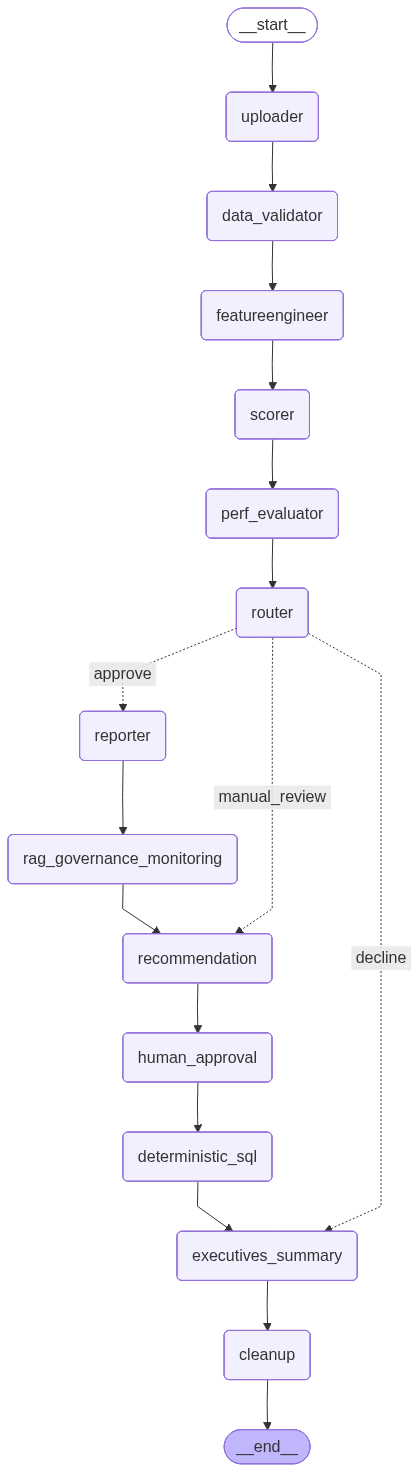

In [57]:
# This generates a PNG of my specific LangGraph workflow structure

display(Image(app.get_graph().draw_mermaid_png()))

In [58]:
from datetime import datetime
end = datetime.now(ZoneInfo("America/New_York"))
duration = end - start

print(f"Started:  {start}")
print(f"Finished: {end}")
print(f"\nDuration: {duration}")                    # 0:00:02.351234
print(f"Duration: {duration.total_seconds():.3f} seconds")

Started:  2026-07-06 15:16:32.312365-04:00
Finished: 2026-07-06 15:17:45.143620-04:00

Duration: 0:01:12.831255
Duration: 72.831 seconds
